# Análisis de Hacker News con MongoDB

## 1. Introducción

Este proyecto implementa un pipeline completo de análisis de datos utilizando:

API pública de Hacker News

MongoDB como base de datos NoSQL

Python para extracción y procesamiento

Pandas para análisis

Generación automática de reportes en Excel

## Importación de librerías

In [22]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

from pymongo import MongoClient
from concurrent.futures import ThreadPoolExecutor


## 3. Conexión a MongoDB

In [23]:
client = MongoClient("mongodb://localhost:27017/")

db = client["hackernews"]
collection = db["posts"]


## 4. Obtener IDs de posts populares

In [24]:
ids = requests.get(
    "https://hacker-news.firebaseio.com/v0/topstories.json"
).json()

len(ids)


500

## 5. Función para descargar posts

In [25]:
def download_post(post_id):

    url = f"https://hacker-news.firebaseio.com/v0/item/{post_id}.json"

    try:
        r = requests.get(url, timeout=5)
        return r.json()
    
    except:
        return None


## 6. Descarga paralela de datos

In [26]:
posts = []

with ThreadPoolExecutor(max_workers=20) as executor:

    results = executor.map(download_post, ids[:500])

    for post in results:
        if post:
            posts.append(post)

print("Posts descargados:", len(posts))


Posts descargados: 500


## 7. Guardar datos en MongoDB

In [27]:
collection.insert_many(posts)


InsertManyResult([ObjectId('69af636d5a5c566b6ae58c44'), ObjectId('69af636d5a5c566b6ae58c45'), ObjectId('69af636d5a5c566b6ae58c46'), ObjectId('69af636d5a5c566b6ae58c47'), ObjectId('69af636d5a5c566b6ae58c48'), ObjectId('69af636d5a5c566b6ae58c49'), ObjectId('69af636d5a5c566b6ae58c4a'), ObjectId('69af636d5a5c566b6ae58c4b'), ObjectId('69af636d5a5c566b6ae58c4c'), ObjectId('69af636d5a5c566b6ae58c4d'), ObjectId('69af636d5a5c566b6ae58c4e'), ObjectId('69af636d5a5c566b6ae58c4f'), ObjectId('69af636d5a5c566b6ae58c50'), ObjectId('69af636d5a5c566b6ae58c51'), ObjectId('69af636d5a5c566b6ae58c52'), ObjectId('69af636d5a5c566b6ae58c53'), ObjectId('69af636d5a5c566b6ae58c54'), ObjectId('69af636d5a5c566b6ae58c55'), ObjectId('69af636d5a5c566b6ae58c56'), ObjectId('69af636d5a5c566b6ae58c57'), ObjectId('69af636d5a5c566b6ae58c58'), ObjectId('69af636d5a5c566b6ae58c59'), ObjectId('69af636d5a5c566b6ae58c5a'), ObjectId('69af636d5a5c566b6ae58c5b'), ObjectId('69af636d5a5c566b6ae58c5c'), ObjectId('69af636d5a5c566b6ae58c

## 8. Cargar datos desde MongoDB

In [28]:
data = list(collection.find())

df = pd.DataFrame(data)

df.head()


,_id,by,descendants,id,kids,score,time,title,type,url,text
0,69af5f505a5c566b6ae58a4b,nextos,35.0,47316880,"[47317333, 47317445, 47317281, 47316951, 47317...",142,1773096909,Sir Tony Hoare has died,story,http://lefenetrou.blogspot.com/2026/03/in-memo...,NaN
1,69af5f505a5c566b6ae58a4c,imadr,52.0,47311815,"[47313477, 47313184, 47316867, 47312761, 47313...",357,1773075742,Building a Procedural Hex Map with Wave Functi...,story,https://felixturner.github.io/hex-map-wfc/arti...,NaN
2,69af5f505a5c566b6ae58a4d,TechTechTech,57.0,47311484,"[47314161, 47313877, 47312898, 47316675, 47314...",219,1773074619,JSLinux Now Supports x86_64,story,https://bellard.org/jslinux/,NaN
3,69af5f505a5c566b6ae58a4e,dahlia,323.0,47310160,"[47316829, 47315293, 47315788, 47317446, 47311...",299,1773069173,Is legal the same as legitimate: AI reimplemen...,story,https://writings.hongminhee.org/2026/03/legal-...,NaN
4,69af5f505a5c566b6ae58a4f,Hooke,10.0,47315079,"[47317121, 47315308, 47317297, 47315896, 47315...",42,1773088365,The first airplane fatality,story,https://www.amusingplanet.com/2026/03/thomas-s...,NaN


## 9. Limpieza básica de datos

In [29]:
df = df[["by","title","score","time","type"]]

df["time"] = pd.to_datetime(df["time"], unit="s")

df["hour"] = df["time"].dt.hour


## 10. Top usuarios por score total

In [30]:
top_users = (
    df.groupby("by")["score"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_users


by
todsacerdoti      4403
JumpCrisscross    2571
morsch            2371
LorenDB           2128
shannoncc         2117
greyface-         2096
enraged_camel     2048
mudkipdev         2032
doener            1940
surprisetalk      1930
Name: score, dtype: int64

## 11. Posts más populares

In [31]:
top_posts = df.sort_values("score", ascending=False).head(10)

top_posts[["title","by","score"]]


,title,by,score
702,Global warming has accelerated significantly,morsch,1186
202,Global warming has accelerated significantly,morsch,1185
276,Judge orders government to begin refunding mor...,JumpCrisscross,1062
774,Judge orders government to begin refunding mor...,JumpCrisscross,1062
725,Tell HN: I'm 60 years old. Claude Code has re-...,shannoncc,1059
226,Tell HN: I'm 60 years old. Claude Code has re-...,shannoncc,1058
273,Wikipedia was in read-only mode following mass...,greyface-,1048
773,Wikipedia was in read-only mode following mass...,greyface-,1048
766,Tech employment now significantly worse than t...,enraged_camel,1024
268,Tech employment now significantly worse than t...,enraged_camel,1024


## 12. Actividad por hora

In [32]:
activity_hour = df.groupby("hour").size()

activity_hour


hour
0     50
1     16
2     24
3     16
4     26
5     22
6     20
7     11
8     22
9     28
10    30
11    29
12    22
13    40
14    54
15    64
16    70
17    84
18    61
19    78
20    76
21    60
22    48
23    49
dtype: int64

## 13. Visualización de actividad

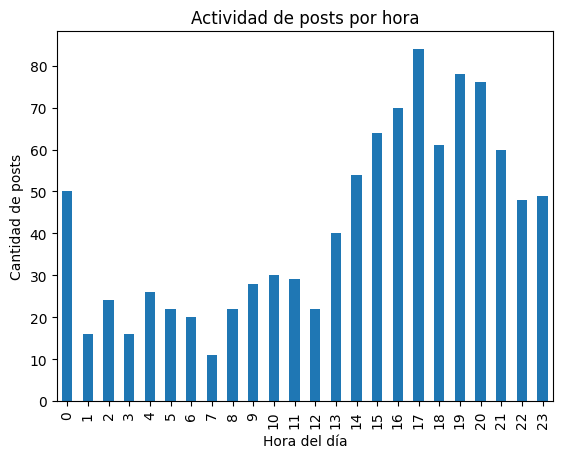

In [33]:
plt.figure()

activity_hour.plot(kind="bar")

plt.title("Actividad de posts por hora")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de posts")

plt.show()


## 14. Relación entre longitud del título y popularidad

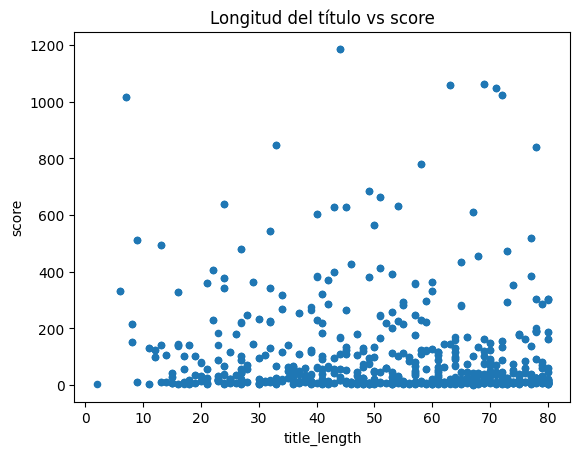

In [34]:
df["title_length"] = df["title"].str.len()

df.plot.scatter(
    x="title_length",
    y="score"
)

plt.title("Longitud del título vs score")
plt.show()


## 15. Automatización de reportes

In [36]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
with pd.ExcelWriter("reporte_hackernews.xlsx") as writer:

    df.to_excel(writer, sheet_name="dataset")

    top_users.to_excel(writer, sheet_name="top_users")

    top_posts.to_excel(writer, sheet_name="top_posts")

    activity_hour.to_excel(writer, sheet_name="activity_hour")
